In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions
S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [3]:
def average_parameters(data, dbscan_labels):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    dict_obj = {}
    dict_obj['photons'] = np.zeros(len(labels))
    dict_obj['frames'] = np.zeros(len(labels))
    for column in np.array(data.columns):
        if column == 'index':
            continue
        else:
            dict_obj[column] = np.zeros(len(labels))
    
    for label in labels:
        for column in np.array(data.columns):
            if column == 'index':
                continue
            elif column in ['A_B', 'A_G', 'A_R']:
                dict_obj[column][label] = np.sum(data[column][dbscan_labels == label])
            else:
                dict_obj[column][label] = np.mean(data[column][dbscan_labels == label])
        dict_obj['frames'][label] = len(data[column][dbscan_labels == label])
        dict_obj['photons'][label] = np.sum(data['A_B'][dbscan_labels == label]) + np.sum(data['A_G'][dbscan_labels == label]) + np.sum(data['A_R'][dbscan_labels == label])
    dict_obj['A_B'] = dict_obj['A_B']/dict_obj['photons']
    dict_obj['A_G'] = dict_obj['A_G']/dict_obj['photons']
    dict_obj['A_R'] = dict_obj['A_R']/dict_obj['photons']
    df = pd.DataFrame.from_dict(dict_obj)
    return df

In [4]:
def extract_single_molecules(localisation_files, chi_val=None, min_cluster_size=10):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    for i, file in enumerate(localisation_files):
        loc_data = pd.read_hdf(file, columns=columns)
        if chi_val is None:
            chi_val = np.median(loc_data['chi_sqr'])
        loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
        loc_data = loc_data[loc_data['xc_err'] < 1]
        loc_data = loc_data[loc_data['yc_err'] < 1]
        loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
        loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] > 500]
        loc_data = loc_data.reset_index()
        X = np.vstack([loc_data['xc'], loc_data['yc']]).T
        loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
        hdb = HDBSCAN(min_cluster_size=min_cluster_size, cluster_selection_epsilon=loc_precision)
        print('Starting DBSCAN')
        hdb.fit(X)
        print('Finished DBSCAN')
        df = average_parameters(loc_data, hdb.labels_)
        photons = loc_data['A_B']+loc_data['A_G']+loc_data['A_R']
        loc_data['photons'] = photons
        for column in np.array(loc_data.columns):
            if column in ['A_B', 'A_G', 'A_R']:
                loc_data[column] = loc_data[column]/photons
        if i == 0:
            single_frame_database = loc_data
            single_molecule_database = df
        else:
            single_frame_database = pd.concat([single_frame_database, loc_data])
            single_molecule_database = pd.concat([single_molecule_database, df])
    return single_molecule_database.reset_index(), single_frame_database.reset_index()

In [5]:
def collect_traces(data, dbscan_labels, image_stack, image_size=12):
    labels = np.sort(np.unique(dbscan_labels))
    labels = labels[labels > -1]
    trace_matrix = np.zeros([len(labels), image_stack.shape[0]])
    locations = np.zeros([2, len(labels)])

    for i, label in enumerate(labels):
        locations[0, i] = np.nanmean(data['xc'][dbscan_labels == label].to_numpy())
        locations[1, i] = np.nanmean(data['yc'][dbscan_labels == label].to_numpy())
        xmin = int(locations[0, i])-int(image_size/2)
        xmax = int(locations[0, i])+int(image_size/2)
        ymin = int(locations[1, i])-int(image_size/2)
        ymax = int(locations[1, i])+int(image_size/2)
        trace_matrix[i, :] = np.sum(np.sum(image_stack[:, xmin:xmax, ymin:ymax], axis=-1), axis=-1)
        print(
                "Summed trace {}/{}".format(
                    i + 1, len(labels)
                ),
                end="\r",
                flush=True,
            )

    return locations, trace_matrix

In [6]:
def extract_single_molecule_traces(localisation_file, chi_val=None):
    columns = ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R',
       'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err',
       'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err']

    image_file = localisation_file.split('.')[0]+'.ome.tif'
    metadata = localisation_file.split('.')[0]+'_metadata.txt'
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata)
    image_data, _, _ = IO.read_tiff_tophotoelectrons(image_file, smoothing_function, gain_map=gain[x_coord:x_coord+width, y_coord:y_coord+height], offset_map=offset[x_coord:x_coord+width, y_coord:y_coord+height], rqe=rqe[x_coord:x_coord+width, y_coord:y_coord+height], read_noise=readnoise[x_coord:x_coord+width, y_coord:y_coord+height], frame=np.arange(750))
    loc_data = pd.read_hdf(localisation_file, columns=columns)
    if chi_val is None:
        chi_val = np.median(loc_data['chi_sqr'])
    loc_data = loc_data[loc_data['chi_sqr'] < chi_val]
    loc_data = loc_data[loc_data['xc_err'] < 1]
    loc_data = loc_data[loc_data['yc_err'] < 1]
    loc_data = loc_data[loc_data['frame'] > 100]
    loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] < 10000]
    loc_data = loc_data[loc_data['A_B']+loc_data['A_G']+loc_data['A_R'] > 500]
    loc_data = loc_data.reset_index()
    X = np.vstack([loc_data['xc'], loc_data['yc']]).T
    loc_precision = 0.5*(np.mean(loc_data['xc_err']) + np.mean(loc_data['yc_err']))
    hdb = DBSCAN(min_samples=10, eps=loc_precision)
    hdb.fit(X)
    locations, trace_matrix = collect_traces(loc_data, hdb.labels_, image_data)
    return locations, trace_matrix, image_data

In [7]:
#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = 'C:/Users/kbhc756/OneDrive - AZCollaboration/Documents/pyS3M-main-20250716/pyS3M-main/Camera_Calibrations/Ximea_Camera'
#data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [8]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [9]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 12
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), 1.2)
camera_parameters["offset"] = np.full((image_size, image_size), 100)
camera_parameters["variance"] = np.full((image_size, image_size), 0.9)
camera_parameters["readnoise"] = np.full((image_size, image_size), 0.2)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]

camera_parameters["masks"] = M_F.get_masks(size_x = image_size, size_y = image_size)
camera_parameters["masks"] = masks

In [10]:
#dye_data_folders = np.array([r'C:\Users\kbhc756\temp_data\20250717_BiotinDyeTemp\ATTO488_50PM_PCA_PCD',r'C:\Users\kbhc756\temp_data\20250717_BiotinDyeTemp\ATTO655_50PM _PCA_PCD',r'C:\Users\kbhc756\temp_data\20250717_BiotinDyeTemp\ATTO700_50PM _PCA_PCD'])
#dye_data_folders = np.array([r'C:\Users\kbhc756\temp_data\Atto620_PCA_PCD_Tx_50pMDye',r'C:\Users\kbhc756\temp_data\Atto647N_PCA_PCD_Tx_20pMDye\20mW_638_1_635LP_1'])
#dye_data_folders = np.array([r'C:\Users\kbhc756\temp_data\ATTO514_50pM_PCAPCDTx',r'C:\Users\kbhc756\temp_data\ATTO520_50pM_PCAPCDTx',r'C:\Users\kbhc756\temp_data\ATTORho6G_50pM_PCAPCDTx\30p_515_LP515_1'])
dye_data_folders = np.array([r'C:\Users\kbhc756\temp_data\20250729 BiotiinylatedDyes\ATTO594_50pM_abitconc\40p_NF_785SP_1_488_561dichro',r'C:\Users\kbhc756\temp_data\20250729 BiotiinylatedDyes\ATTO633_50pM',r'C:\Users\kbhc756\temp_data\20250729 BiotiinylatedDyes\ATTO647N_50pM\40both638_NF_785SP_1',r'C:\Users\kbhc756\temp_data\20250729 BiotiinylatedDyes\ATTO655_50pM_slighlty_conc\40both638_NF_785SP_1'])
example_folder = dye_data_folders[0]

In [11]:
dye_data_folders[0]

'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro'

In [ ]:
import time

# Wait for 3 hours (10800 seconds)
time.sleep(10800)


In [181]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [232]:
image_files = H_F.file_search(dye_data_folders[3], '.tif', "")

In [233]:
image_files

array(['C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos000_000.ome.tif',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos000_001.ome.tif',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos000_002.ome.tif',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos000_003.ome.tif',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos001_000.ome.tif',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO655_50pM_slighlty_conc\\40both638_NF_785SP_1\\40both638_NF_785SP_1_MMStack_5-Pos001_

In [245]:
photolectron_data, smoothed_data, weights = IO.read_tiff_tophotoelectrons(image_files[3], frame=100, smoothing_function=smoothing_function)

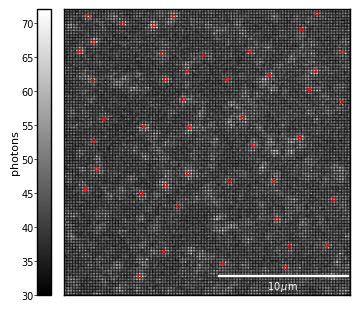

In [246]:
fig, axs = SRes_F.example_spots_singleframe(photolectron_data, pfa=1e-4, peak_wavelength=0.68)

plt.xlim([0, 200])
plt.ylim([0, 200])
plt.show()

In [249]:
#pfas = np.array([1e-3,1e-4,1e-4]) #ATTO488 = 1e-4, ATTO655 = 1e-5, ATTO700 = 1e-700, ATTO 620 1e-4, ATTO647N 1e-4, ATTO633 = 1e-3
pfas = np.array([1e-3, 1e-3, 1e-3, 1e-4])
peak_wavelength = np.array([0.626, 0.651, 0.664,0.680])

In [250]:
#ATTO565_folder = r'C:\Users\kbhc756\temp_data\Atto565_PCA_PCD_Tx_50pMDye'
ATTO594_folder = dye_data_folders[0]
ATTO633_folder = dye_data_folders[1]
ATTO647N_folder = dye_data_folders[2]
ATTO655_folder = dye_data_folders[3]
#ATTO488_folder = dye_data_folders[0]
#ATTO700_folder = dye_data_folders[2]
#ATTO514_folder = dye_data_folders[0]
#ATTO520_folder = dye_data_folders[1]
#ATTORho6G_folder = dye_data_folders[2]


In [251]:
for i, image_folder in enumerate(dye_data_folders):
    SRes_F.fit_SM_data(image_folder, smoothing_function, gain, offset, rqe, readnoise, pfa=pfas[i], peak_wavelength=peak_wavelength[i])

LM fitting: 100%|████████████████████████████████████████████████████████████████| 1900/1900 [02:04<00:00, 15.23task/s]


In [252]:
localisation_files = H_F.file_search(ATTO594_folder, '.h5', 'Pos')

In [253]:
localisation_files

array(['C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos000_000.h5',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos000_001.h5',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos000_002.h5',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos000_003.h5',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos001_000.h5',
       'C:\\Users\\kbhc756\\temp_data\\20250729 BiotiinylatedDyes\\ATTO594_50pM_abitconc\\40p_NF_785SP_1_488_561dichro\\40p_NF_785SP_1_MMStack_2-Pos001_001.h5',
       'C:\\Users\\kbhc756\\temp_d

In [254]:
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files, chi_val=2)
single_molecule_database.to_hdf(os.path.join(ATTO594_folder, 'Single_molecule_database.h5'), key='data', format="table")
single_frame_database.to_hdf(os.path.join(ATTO594_folder, 'Single_frame_database.h5'), key='data', format="table")

Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN


In [255]:
#localisation files and DB scan ATTO620
#ATTO520_folder = dye_data_folders[1]
localisation_files = H_F.file_search(ATTO633_folder, '.h5', 'Pos')
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files, chi_val=2)
single_molecule_database.to_hdf(os.path.join(ATTO633_folder, 'Single_molecule_database.h5'), key='data', format="table")
single_frame_database.to_hdf(os.path.join(ATTO633_folder, 'Single_frame_database.h5'), key='data', format="table")


Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN


In [256]:
#localisation files and DB scan ATTO647
localisation_files = H_F.file_search(ATTO647N_folder, '.h5', 'Pos')
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files, chi_val=2)
single_molecule_database.to_hdf(os.path.join(ATTO647N_folder, 'Single_molecule_database.h5'), key='data', format="table")
single_frame_database.to_hdf(os.path.join(ATTO647N_folder, 'Single_frame_database.h5'), key='data', format="table")


Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN


In [257]:
localisation_files = H_F.file_search(ATTO655_folder, '.h5', 'Pos')
single_molecule_database, single_frame_database = extract_single_molecules(localisation_files, chi_val=2)
single_molecule_database.to_hdf(os.path.join(ATTO655_folder, 'Single_molecule_database.h5'), key='data', format="table")
single_frame_database.to_hdf(os.path.join(ATTO655_folder, 'Single_frame_database.h5'), key='data', format="table")


Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN
Starting DBSCAN
Finished DBSCAN


In [167]:
analysis_files = H_F.file_search(ATTO520_folder, '.h5', 'database')
analysis_files

array(['C:\\Users\\kbhc756\\temp_data\\ATTO520_50pM_PCAPCDTx\\Single_frame_database.h5',
       'C:\\Users\\kbhc756\\temp_data\\ATTO520_50pM_PCAPCDTx\\Single_molecule_database.h5'],
      dtype='<U76')

In [168]:
single_frame_database = pd.read_hdf(analysis_files[0])
single_molecule_database = pd.read_hdf(analysis_files[1])

In [170]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
shortpass_filter = 'semrock-bsp01-785r'
longpass_red_filter = 'semrock-blp01-635r'

dichroic_514 = 'semrock-di03-r514-t1-25x36'

longpass_blue_filter = 'semrock-blp01-488r'
bandpass_blue_filter = 'semrock-ff01-520-44'

longpass_green_filter = 'semrock-blp02-561r'
bandpass_green_filter = 'semrock-ff01-582-64'

longpass_514_filter = 'semrock-ff01-515-lp'
bandpass_514_filter = 'semrock-ff01-540-80'

filters = [longpass_514_filter,bandpass_514_filter,dichroic_514]
dye = 'ATTO 520'
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
dye_pixel_efficiency = dye_pixel_efficiency/np.sum(dye_pixel_efficiency)
print(np.sum(dye_pixel_efficiency))

0.9999999999999999


In [171]:
filter

array([3.30457015e-10, 4.93980715e-10, 5.68993725e-10, 9.12031480e-10,
       5.55365248e-10, 8.18619421e-10, 4.75656305e-10, 8.86416332e-10,
       5.92923624e-10, 8.34093049e-10, 6.30166450e-10, 5.31615716e-10,
       6.77507359e-10, 2.64378145e-10, 5.75813538e-10, 5.18638096e-10,
       6.55209526e-10, 8.92232643e-10, 6.97484985e-10, 1.06711244e-09,
       4.50548208e-10, 1.05297369e-09, 6.49447665e-10, 5.53207131e-10,
       2.04894073e-10, 6.56737884e-11, 1.71746494e-10, 1.56728879e-10,
       1.97009436e-10, 8.92081219e-10, 5.79216783e-10, 4.60834978e-10,
       1.12298683e-10, 9.76990424e-11, 1.85840927e-10, 1.10297585e-10,
       4.99040805e-11, 4.81939304e-11, 8.14876357e-11, 4.01653079e-11,
       2.94381924e-11, 4.03324863e-11, 5.03088914e-11, 4.47063069e-11,
       2.26585306e-10, 3.64543345e-10, 8.03926250e-11, 4.39999381e-11,
       3.06216081e-11, 3.26840686e-11, 3.14712766e-11, 2.84909250e-11,
       2.42203276e-11, 3.11294737e-11, 2.68192870e-11, 2.79999034e-11,
      

In [172]:
#ATTO488 = S_F.get_dye_or_filter_data(dye, wavelength)
filter = np.prod(S_F.get_dye_or_filter_data(filters, wavelength, dye_or_filter=False), axis=0)

In [173]:
filter = filter*objective_T

In [241]:
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_rawspectra(ATTO488*filter, wavelength, pixel_QYs)

In [174]:
filters = S_F.get_dye_or_filter_data(filters, wavelength, dye_or_filter=False)

NameError: name 'ATTO488' is not defined

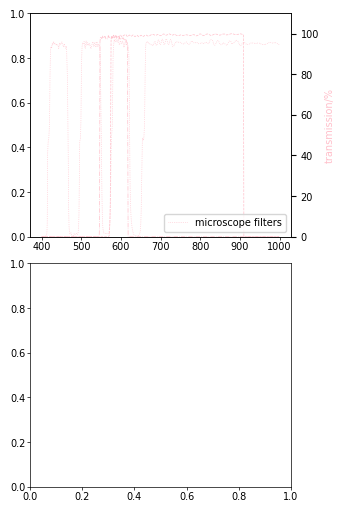

In [96]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1,1], height=5)

ax2 = axs[0].twinx()  # instantiate a second Axes that shares the same x-axis
ax2.set_ylabel('transmission/%', color='#ffc0cb')  # we already handled the x-label with ax1

linestyles = np.array(['--', '-.', ':'])
for i in np.arange(len(filters)):
    if i != 2:
        ax2.plot(wavelength, 100*filters[i, :], color='#ffc0cb', lw=0.5, ls=linestyles[i])
    if i == 2:
        ax2.plot(wavelength, 100*filters[i, :], color='#ffc0cb', lw=0.5, ls=linestyles[i], label='microscope filters')
        
ax2.set_ylim([0, 110])
ax2.legend(loc='best')


axs[0] = plotter.line_plot(axs=axs[0], x=wavelength, y=np.squeeze(ATTO488)/np.max(ATTO488), color='white', xaxislabel='wavelength/nm', yaxislabel='fluo/norm', label='ATTO 488')

axs[0].set_ylim(0, 1.1)
axs[0].set_xlim(400, 800)
axs[0].legend(loc='best')

#filtered_ATTO565 = np.multiply(filters,ATTO565)

#axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=np.squeeze(filtered_ATTO565)/np.max(filtered_ATTO565), color='white', xaxislabel='wavelength/nm', yaxislabel='fluo/norm', label='ATTO  after filters')
#axs[1].legend(loc='best')

#axs[1].set_ylim(0, 1.05)
#axs[1].set_xlim(550, 800)

#folder = example_folder
#plt.savefig(os.path.join(folder, 'ATTO565_Spectra.svg'), dpi=600)
plt.show()

In [148]:
atto565_maxt = 0.8
atto565_maxl = 0.5
atto565_maxr = 0.5
atto565_ts=0.5

atto488_maxt = 0.9 #this is good, uses the full frame of the turniry plot (or most of it)
atto488_maxl = 0.9
atto488_maxr = 0.9
atto488_ts=0.9

atto655_maxt = 1
atto655_maxl = 0.5
atto655_maxr = 0.5
atto655_ts=0.5

atto700_maxt = 1
atto700_maxl = 0.5
atto700_maxr = 0.5
atto700_ts=0.5

unity_maxt = 1
unity_maxl = 1
unity_maxr = 1
unity_ts = 1

In [149]:
folder

NameError: name 'folder' is not defined

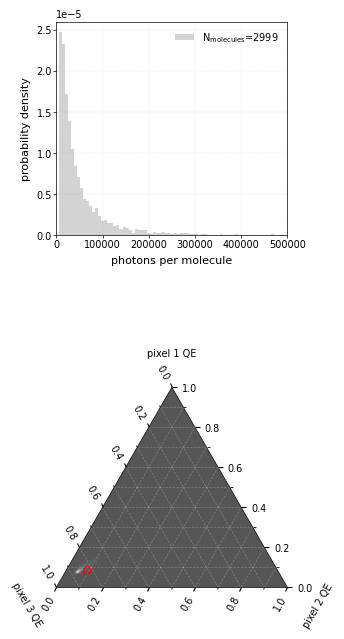

In [175]:
fig, ax = plotter.one_column_plot(npanels=2, ratios=[0.5, 1])


fig, ax = plotter.ternary_contour_plot(fig, ax, single_molecule_database['A_R'], single_molecule_database['A_G'], single_molecule_database['A_B'], 
                                       gridsize=500,
                                  R=dye_pixel_efficiency[2], G=dye_pixel_efficiency[1], B=dye_pixel_efficiency[0], maxt=unity_maxt, 
                                       maxl=unity_maxl, 
                                maxr=unity_maxr, trianglesize=unity_ts,
                                       maj_loc=0.2,
                                       min_loc=0.1,
                                 lws=1,
                                 ecolour='red')

n_molecules = len(single_molecule_database['photons'])
ax[0] = plotter.histogram_plot(axs=ax[0], data=single_molecule_database['photons'], bins=np.histogram_bin_edges(single_molecule_database['photons'], 'fd'), histcolor='#d3d3d3', xaxislabel='photons per molecule', label=r'N$_\mathsf{molecules}$='+str(int(n_molecules)))
ax[0].set_xlim([0, 5e5])
ax[0].legend(loc='best', frameon=False)

#folder = ATTO565_folder
#plt.savefig(os.path.join(folder, 'ATTO565_permolecule_objective.svg'), dpi=600)
plt.show()

In [ ]:
plt.hist(single_frame_database['A_R'])
plt.hist(single_frame_database['A_G'])

(0.0, 1.0)

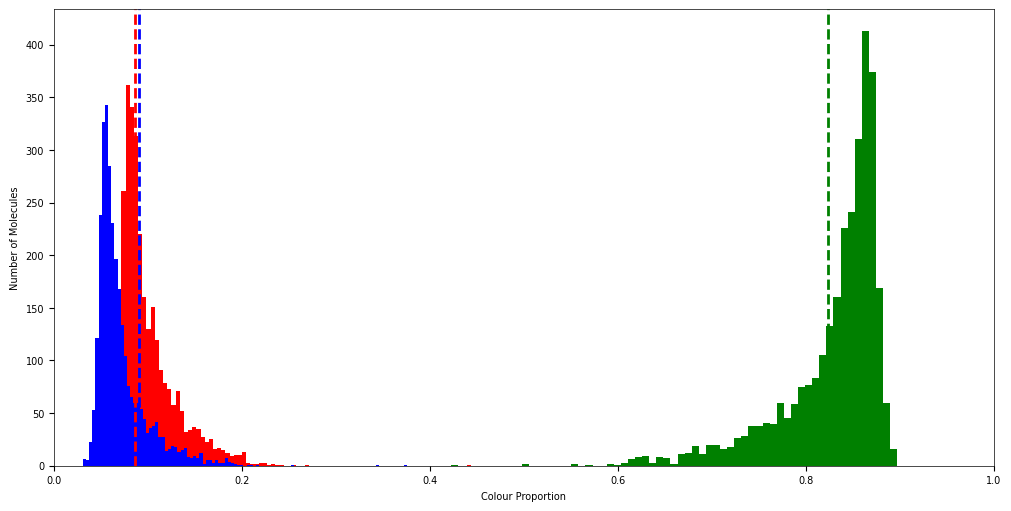

In [176]:
plt.figure(figsize = [10,5])
plt.hist(single_molecule_database['A_R'], color='red', bins=np.histogram_bin_edges(single_molecule_database['A_R'], 'fd'))
plt.hist(single_molecule_database['A_G'], color='green', bins=np.histogram_bin_edges(single_molecule_database['A_G'], 'fd'))
plt.hist(single_molecule_database['A_B'], color='blue', bins=np.histogram_bin_edges(single_molecule_database['A_B'], 'fd'))

plt.axvline(x=dye_pixel_efficiency[2], color='red', linestyle='--', linewidth=2)
plt.axvline(x=dye_pixel_efficiency[1], color='green', linestyle='--', linewidth=2)
plt.axvline(x=dye_pixel_efficiency[0], color='blue', linestyle='--', linewidth=2)

plt.xlabel("Colour Proportion")
plt.ylabel("Number of Molecules")
plt.xlim(0,1)

In [178]:
np.median(single_frame_database['photons'])
#dye_pixel_efficiency[1]

848.2296

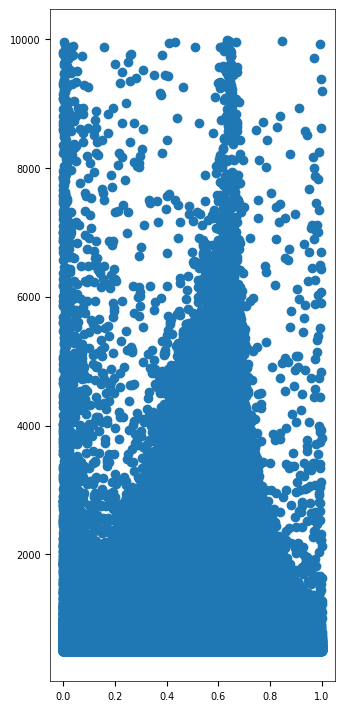

In [166]:
plt.scatter(single_frame_database['A_G'],single_frame_database['photons'])

Text(0, 0.5, 'Number of Molecules')

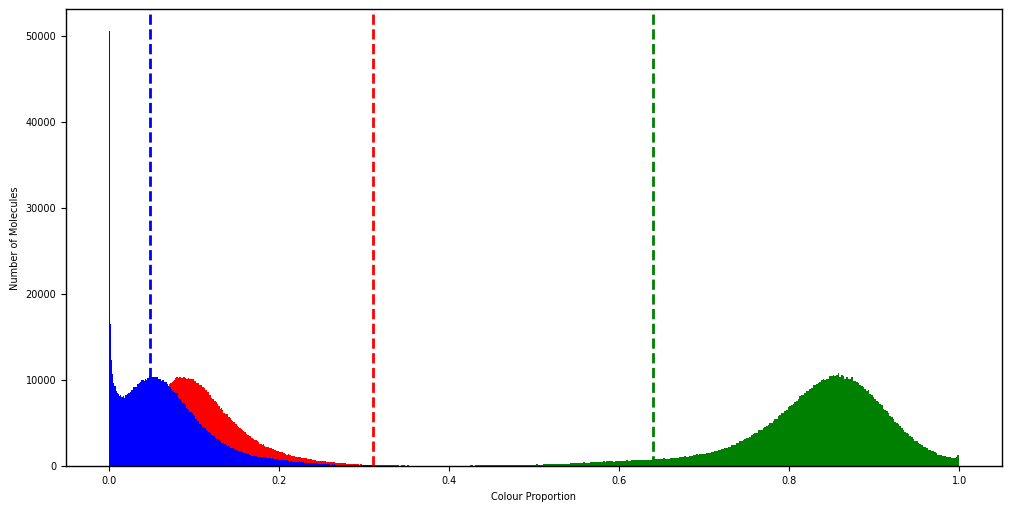

In [95]:
plt.figure(figsize = [10,5])
plt.hist(single_frame_database['A_R'], color='red', bins=np.histogram_bin_edges(single_frame_database['A_R'], 'fd'))
plt.hist(single_frame_database['A_G'], color='green', bins=np.histogram_bin_edges(single_frame_database['A_G'], 'fd'))
plt.hist(single_frame_database['A_B'], color='blue', bins=np.histogram_bin_edges(single_frame_database['A_B'], 'fd'))

plt.axvline(x=dye_pixel_efficiency[2], color='red', linestyle='--', linewidth=2)
plt.axvline(x=dye_pixel_efficiency[1], color='green', linestyle='--', linewidth=2)
plt.axvline(x=dye_pixel_efficiency[0], color='blue', linestyle='--', linewidth=2)

plt.xlabel("Colour Proportion")
plt.ylabel("Number of Molecules")

In [12]:
plt.plot(trace_matrix[80, :])


NameError: name 'trace_matrix' is not defined